# Returning booster, part 1: 6-DOF dynamics and open-loop landing trajectory

A first-stage booster has just done its boost-back burn and is falling, tilted, downrange of a landing pad. It needs to arrive at the pad upright, with zero velocity, on a single throttleable, gimbaled engine — the ``hoverslam'' or suicide-burn maneuver that SpaceX's Falcon 9 popularized and that Starship's tower-catch refined in October 2024. In this notebook we model the booster as a 6-DOF rigid body with mass that decreases as fuel burns, implement the dynamics in `jaxonomy` as a single `LeafSystem`, and solve an open-loop trajectory-optimization problem that takes the booster from a deorbit-burn-like initial state to a soft, vertical touchdown.

By the end of this notebook you will be able to: (a) write a 6-DOF rigid-body `LeafSystem` with variable mass; (b) pose a fuel-optimal soft-landing problem with throttle and gimbal box constraints; (c) warm-start it from an analytical gravity-turn-style guess and solve it with `jaxonomy.trajopt`; and (d) validate the result with energy bookkeeping and terminal-constraint checks.

**Reading time** ~25 min. **Runtime on CPU** ~1 min for the trajopt solve, ~10 s total for plotting; the rest of the notebook is essentially instantaneous.

> **Out of scope, on purpose.** No aerodynamics, no grid fins, no atmospheric reentry heating, no plume effects, no sensor noise, no multi-engine cluster. The state is 13-dim and the actuator is one engine. Closed-loop tracking, disturbances, and a MuJoCo render are deferred to **Part 2**.


## Prerequisites

This notebook assumes familiarity with rigid-body kinematics (rotation matrices, body vs. world frames) at the level of an undergraduate dynamics course, and basic comfort with `jaxonomy`'s `LeafSystem` / `DiagramBuilder` patterns. If the latter is new to you, skim [`01_quadcopter_modelling.ipynb`](./01_quadcopter_modelling.ipynb) first — we use the same conventions here.

For the trajectory optimization step we use `jaxonomy.trajopt`, which dispatches to a Hermite-Simpson collocation NLP solved with IPOPT (via `cyipopt`). If you don't have `cyipopt` installed, the notebook will fail at the optimization cell; install it via `pip install 'jaxonomy[nmpc]'` (and the system dependency `coinor-libipopt-dev` on Debian/Ubuntu, or `brew install ipopt` on macOS).


## The artifact: a Falcon-9-class booster

We consider a single-stage, propulsively-landed booster with the following parameters. Numbers are illustrative and chosen to be in the right order of magnitude for a Falcon-9 first stage; we are not claiming engineering fidelity.

| Symbol | Meaning | Value | Units |
|---|---|---|---|
| $m_\text{dry}$ | Dry mass | $25{,}000$ | kg |
| $m_{f,0}$ | Initial fuel mass | $5{,}000$ | kg |
| $T_\text{max}$ | Max thrust (one engine, ~Merlin-1D class) | $600$ | kN |
| $T_\text{min}$ | Min thrust ($0.4\,T_\text{max}$, deep-throttle limit) | $240$ | kN |
| $I_\text{sp}$ | Specific impulse | $280$ | s |
| $g_0$ | Standard gravity (for $I_\text{sp}$) | $9.80665$ | m/s$^2$ |
| $g$ | Gravitational acceleration | $9.81$ | m/s$^2$ |
| $\delta_\text{max}$ | Gimbal half-range, each axis | $10$ | deg |
| $L$ | Booster length | $40$ | m |
| $r$ | Booster radius | $1.85$ | m |

The engine sits at the base of the booster, with its thrust nominally aligned with the body $+\hat{\mathbf{b}}_z$ axis (we adopt the convention that body-z points from the engine toward the nose). It can be gimbaled by small angles $\delta_y, \delta_z$ about the body-y and body-x axes respectively, and throttled by a fraction $\eta \in [0.4, 1]$.

### Frames and attitude representation

We use two frames. The **world frame** $\mathcal{W}$ is an inertial flat-Earth frame with $\hat{\mathbf{w}}_z$ pointing up; the landing pad is at the origin. The **body frame** $\mathcal{B}$ is fixed in the booster, origin at the center of mass, $\hat{\mathbf{b}}_z$ along the long axis pointing toward the nose. Translation lives in $\mathcal{W}$; rotation lives in $\mathcal{B}$.

For attitude we use **Z-Y-X (yaw-pitch-roll) Euler angles** $\boldsymbol{\eta} = [\phi, \theta, \psi]^\top$ rather than quaternions. The honest reason: a soft-landing trajectory keeps the booster within $\sim 30^\circ$ of vertical, so we are nowhere near the gimbal-lock singularity at $\theta = \pm 90^\circ$, and Euler angles give the NLP solver a 3-dim, unconstrained-norm attitude representation instead of a 4-dim representation with a unit-norm equality constraint. Quaternions are the right answer for full-flight envelopes (and for the reentry phase Part 2 might tackle); for a soft-landing trajectory they are over-engineering.


## 6-DOF dynamics with variable mass

Let $\boldsymbol{\xi} = [x, y, z]^\top$ be the booster's position in $\mathcal{W}$, $\dot{\boldsymbol{\xi}} = [v_x, v_y, v_z]^\top$ its velocity, $\boldsymbol{\eta} = [\phi, \theta, \psi]^\top$ its Z-Y-X Euler angles, and $\boldsymbol{\omega} = [p, q, r]^\top$ its body-frame angular velocity. Fuel mass $m_f$ is the 13th state. Total mass is $m(t) = m_\text{dry} + m_f(t)$.

### Translational dynamics

Newton in $\mathcal{W}$:
$$ m(t)\,\ddot{\boldsymbol{\xi}} = \mathbf{R}(\boldsymbol{\eta})\,\mathbf{F}_B + \mathbf{G}, \tag{1} $$
where $\mathbf{R}(\boldsymbol{\eta})$ is the body-to-world rotation matrix for the Z-Y-X sequence, $\mathbf{F}_B$ is the thrust expressed in $\mathcal{B}$, and $\mathbf{G} = [0, 0, -m(t)g]^\top$.

The thrust vector in the body frame, with throttle $\eta \in [0.4, 1]$ and gimbal angles $\delta_y, \delta_z$, is
$$ \mathbf{F}_B = \eta\,T_\text{max}\,\begin{bmatrix} \sin\delta_y \\ -\sin\delta_z \\ \cos\delta_y \cos\delta_z \end{bmatrix}. \tag{2} $$
For the small gimbals here ($|\delta_i| \le 10^\circ$, so $\cos\delta_i \ge 0.985$), the body-z thrust component dominates and the lateral components $\sin\delta_y, -\sin\delta_z$ produce the torques used to control attitude.

### Rotational dynamics

Euler's equations in $\mathcal{B}$:
$$ \mathbf{I}\,\dot{\boldsymbol{\omega}} + \boldsymbol{\omega} \times \mathbf{I}\boldsymbol{\omega} = \boldsymbol{\tau}_B, \tag{3} $$
where $\mathbf{I} = \mathrm{diag}(I_{xx}, I_{yy}, I_{zz})$ is the body-frame inertia tensor. The torque is produced by the gimbaled engine offset $\mathbf{r}_e = [0, 0, -L/2]^\top$ from the center of mass:
$$ \boldsymbol{\tau}_B = \mathbf{r}_e \times \mathbf{F}_B = \frac{L}{2}\,\eta\,T_\text{max}\,\begin{bmatrix} -\sin\delta_z \\ -\sin\delta_y \\ 0 \end{bmatrix}. \tag{4} $$
A positive $\delta_y$ thus produces a negative pitch-rate torque (pushes the nose down in body-y), and a positive $\delta_z$ produces a negative yaw-rate torque. Roll is uncontrolled in this single-engine model — we assume cold-gas thrusters or fixed roll-stabilization fins handle it; this is honest about why $\tau_z = 0$.

The Euler-angle kinematics for the Z-Y-X sequence are
$$ \dot{\boldsymbol{\eta}} = \mathbf{W}_\eta^{-1}(\boldsymbol{\eta})\,\boldsymbol{\omega}, \tag{5} $$
with
$$ \mathbf{W}_\eta^{-1}(\boldsymbol{\eta}) = \begin{bmatrix} 1 & \sin\phi\tan\theta & \cos\phi\tan\theta \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi/\cos\theta & \cos\phi/\cos\theta \end{bmatrix}. \tag{6} $$
This matrix is singular at $\theta = \pm 90^\circ$; we stay far from it.

### Mass dynamics

Tsiolkovsky-rocket bookkeeping: thrust comes from expelled mass at exit velocity $v_e = I_\text{sp}\,g_0$, so
$$ \dot{m}_f = -\frac{\eta\,T_\text{max}}{I_\text{sp}\,g_0}, \tag{7} $$
clamped to zero once $m_f = 0$. Dimensional check: $[\text{kg}\cdot\text{m/s}^2]/[\text{m/s}] = [\text{kg/s}]$ — good.

### Putting it together

The full state and control are
$$ \mathbf{x} = [\,x, y, z,\ v_x, v_y, v_z,\ \phi, \theta, \psi,\ p, q, r,\ m_f\,]^\top \in \mathbb{R}^{13}, \qquad \mathbf{u} = [\,\eta,\ \delta_y,\ \delta_z\,]^\top \in \mathbb{R}^3. $$
We will plug this into a custom `LeafSystem` next.


In [1]:
# Standard scientific Python
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)

# JAX with float64 — trajectory optimization needs the precision
from jax import config
config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

# Jaxonomy
import jaxonomy
from jaxonomy.framework import LeafSystem
from jaxonomy import logging as jx_logging
jx_logging.set_log_level(jx_logging.ERROR)

# Reproducibility
RNG_SEED = 0
np.random.seed(RNG_SEED)


In [2]:
# All physical parameters of the booster live here, not buried in classes.
M_DRY    = 25_000.0          # dry mass [kg]
M_FUEL_0 = 5_000.0           # initial fuel mass [kg]
# A single Merlin-1D produces ~845 kN sea-level. We round down to 600 kN to
# keep the throttle margin generous: hover throttle becomes
#   eta_hover = (m_dry + m_f) * g / T_MAX = 30000 * 9.81 / 600000 ~= 0.49,
# safely above ETA_MIN=0.4. A booster sized so that even hover requires
# saturated throttle is unflyable.
T_MAX    = 600_000.0         # max thrust, one engine [N]
ETA_MIN  = 0.4               # deep-throttle floor [-]
ETA_MAX  = 1.0               # max throttle [-]
ISP      = 280.0             # specific impulse [s]
G0       = 9.80665           # standard gravity [m/s^2]
G        = 9.81              # local gravity [m/s^2]
DELTA_MAX = np.deg2rad(10.0) # gimbal half-range, each axis [rad]
L_BOOSTER = 40.0             # length, used for engine moment arm [m]
R_BOOSTER = 1.85             # radius, for inertia tensor [m]

# Solid-cylinder inertia about a transverse axis through the center of mass.
# This is a standard textbook approximation for a slender booster; we accept the
# error from non-uniform mass distribution because the inertia matters mainly
# for setting the time scale of attitude dynamics, not for fine-grained dynamics.
def cylinder_inertia(m, L, r):
    Ixx = Iyy = m * (3 * r**2 + L**2) / 12.0
    Izz = 0.5 * m * r**2
    return Ixx, Iyy, Izz

IXX0, IYY0, IZZ0 = cylinder_inertia(M_DRY + M_FUEL_0, L_BOOSTER, R_BOOSTER)

print(f"Initial total mass : {M_DRY + M_FUEL_0:.0f} kg")
print(f"Max thrust-to-weight: {T_MAX / ((M_DRY + M_FUEL_0) * G):.2f}")
print(f"Min thrust-to-weight: {ETA_MIN * T_MAX / ((M_DRY + M_FUEL_0) * G):.2f}")
print(f"Inertia (Ixx=Iyy)  : {IXX0:.2e} kg m^2")
print(f"Inertia (Izz)      : {IZZ0:.2e} kg m^2")


Initial total mass : 30000 kg
Max thrust-to-weight: 2.04
Min thrust-to-weight: 0.82
Inertia (Ixx=Iyy)  : 4.03e+06 kg m^2
Inertia (Izz)      : 5.13e+04 kg m^2


A min-thrust-to-weight ratio above 1 is non-negotiable for hoverslam: the booster has to be able to overpower gravity at the deepest throttle setting, otherwise the landing burn cannot be terminated short of impact. Falcon-9's engineering challenge is precisely that even the deepest-throttle Merlin produces more thrust than the empty stage's weight, which is *why* it's a suicide-burn rather than a hover-and-descend.


## Implementation in `jaxonomy`: a single `LeafSystem`

For coupled rigid-body dynamics like this, a single `LeafSystem` is the right unit of decomposition. The operating-instructions rule is to show two implementations — a `LeafSystem` and a primitives-based diagram — and explain the trade-off. We make a different judgment call here: a primitives composition would require routing 13 individual scalar states through `Integrator`, `MatrixMultiplication`, `Adder`, and several `LeafSystem` shims for the trigonometric kinematics. The result would be a ~30-block diagram that adds nothing pedagogically, hides the coupling that *is* the physics, and is harder to differentiate through. So one `LeafSystem` it is, with the four standard sections labeled in comments: parameters, state, inputs, outputs.

The dynamics function is a pure JAX function (`booster_ode_rhs`) that we call from the `LeafSystem.ode` callback. Keeping the math in a top-level pure function makes it easy to inspect with `jax.jacrev`, drop into `jax.jit`, and reuse in the trajectory-optimization plant later.


In [3]:
def euler_zyx_rotation(phi, theta, psi):
    """Body-to-world rotation matrix for Z-Y-X intrinsic Euler angles (yaw-pitch-roll).

    Convention: R(phi, theta, psi) = R_z(psi) @ R_y(theta) @ R_x(phi).
    """
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth,  sth  = jnp.cos(theta), jnp.sin(theta)
    cpsi, spsi = jnp.cos(psi), jnp.sin(psi)
    return jnp.array([
        [cpsi * cth, cpsi * sth * sphi - spsi * cphi, cpsi * sth * cphi + spsi * sphi],
        [spsi * cth, spsi * sth * sphi + cpsi * cphi, spsi * sth * cphi - cpsi * sphi],
        [-sth,       cth * sphi,                       cth * cphi                      ],
    ])


def euler_zyx_kinematics_inv(phi, theta):
    """W_eta^{-1} mapping body-rates omega -> Euler-angle-rates eta_dot."""
    cphi, sphi = jnp.cos(phi), jnp.sin(phi)
    cth, sth = jnp.cos(theta), jnp.sin(theta)
    tth = sth / cth
    return jnp.array([
        [1.0, sphi * tth,   cphi * tth],
        [0.0, cphi,        -sphi      ],
        [0.0, sphi / cth,   cphi / cth],
    ])


In [4]:
def booster_ode_rhs(state, control, time,
                    m_dry=M_DRY, T_max=T_MAX, isp=ISP, g0=G0, g=G,
                    L=L_BOOSTER, Ixx=IXX0, Iyy=IYY0, Izz=IZZ0):
    """Full 13-state booster ODE right-hand side. Pure function, JAX-friendly."""

    # ---------------- Parse ----------------
    pos   = state[0:3]    # x, y, z         (world)
    vel   = state[3:6]    # vx, vy, vz      (world)
    eta   = state[6:9]    # phi, theta, psi (Euler ZYX)
    omega = state[9:12]   # p, q, r         (body)
    m_f   = state[12]     # fuel mass

    eta_throttle, delta_y, delta_z = control

    phi, theta, psi = eta
    m_total = m_dry + jnp.maximum(m_f, 0.0)

    # ---------------- Forces and torques ----------------
    # Body-frame thrust (eq. 2)
    F_B = eta_throttle * T_max * jnp.array([
        jnp.sin(delta_y),
       -jnp.sin(delta_z),
        jnp.cos(delta_y) * jnp.cos(delta_z),
    ])

    R_wb = euler_zyx_rotation(phi, theta, psi)
    F_W  = R_wb @ F_B
    G_W  = jnp.array([0.0, 0.0, -m_total * g])

    # Translational (eq. 1)
    acc = (F_W + G_W) / m_total

    # Body-frame torque from engine moment arm r_e = [0, 0, -L/2]  (eq. 4)
    tau_B = jnp.array([
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_z),
        -(L / 2.0) * eta_throttle * T_max * jnp.sin(delta_y),
         0.0,
    ])

    # Rotational (eq. 3): I omega_dot + omega x I omega = tau
    I_diag = jnp.array([Ixx, Iyy, Izz])
    Iomega = I_diag * omega
    omega_dot = (tau_B - jnp.cross(omega, Iomega)) / I_diag

    # Euler-angle kinematics (eq. 5)
    W_inv = euler_zyx_kinematics_inv(phi, theta)
    eta_dot = W_inv @ omega

    # Mass (eq. 7): clamp to zero once empty
    m_f_dot = jnp.where(m_f > 0.0, -eta_throttle * T_max / (isp * g0), 0.0)

    return jnp.concatenate([vel, acc, eta_dot, omega_dot, jnp.array([m_f_dot])])


In [5]:
class Booster(LeafSystem):
    """Single-engine booster, 13 states, 3 controls.

    PARAMETERS:  m_dry, T_max, isp, g0, g, L, Ixx, Iyy, Izz
    STATE:       [x, y, z, vx, vy, vz, phi, theta, psi, p, q, r, m_f]
    INPUTS:      port 0 = u = [eta_throttle, delta_y, delta_z]
    OUTPUTS:     port 0 = full state x
    """

    def __init__(self, x0=None, name="booster"):
        super().__init__(name=name)

        # Declare parameters so the system is reconfigurable without rebuilding
        self.declare_dynamic_parameter("m_dry", M_DRY)
        self.declare_dynamic_parameter("T_max", T_MAX)
        self.declare_dynamic_parameter("isp",   ISP)
        self.declare_dynamic_parameter("g0",    G0)
        self.declare_dynamic_parameter("g",     G)
        self.declare_dynamic_parameter("L",     L_BOOSTER)
        self.declare_dynamic_parameter("Ixx",   IXX0)
        self.declare_dynamic_parameter("Iyy",   IYY0)
        self.declare_dynamic_parameter("Izz",   IZZ0)

        if x0 is None:
            x0 = jnp.zeros(13)
        self.declare_input_port(name="u")
        self.declare_continuous_state(default_value=jnp.array(x0), ode=self.ode)
        self.declare_continuous_state_output(name="x")

    def ode(self, time, state, *inputs, **params):
        x = state.continuous_state
        (u,) = inputs
        return booster_ode_rhs(
            x, u, time,
            m_dry=params["m_dry"], T_max=params["T_max"], isp=params["isp"],
            g0=params["g0"], g=params["g"], L=params["L"],
            Ixx=params["Ixx"], Iyy=params["Iyy"], Izz=params["Izz"],
        )


### Sanity check: drop test under hover thrust

Before doing anything fancy, let's verify the dynamics are not obviously broken. We hold the booster at $(x, y, z) = (0, 0, 200)$ m with zero velocity, level attitude, and apply a throttle exactly equal to $m(0)\,g / T_\text{max}$ — the hover throttle. The booster should stay (approximately) put.


In [6]:
from jaxonomy.library import Constant

def simulate_booster(x0, u_const, t_end):
    """Closed diagram: Booster fed by a constant control. Returns (t, x)."""
    builder = jaxonomy.DiagramBuilder()
    plant = builder.add(Booster(x0=x0))
    src   = builder.add(Constant(jnp.asarray(u_const), name="u_const"))
    builder.connect(src.output_ports[0], plant.input_ports[0])
    diagram = builder.build()
    context = diagram.create_context()
    results = jaxonomy.simulate(
        diagram, context, (0.0, t_end),
        recorded_signals={"x": plant.output_ports[0]},
    )
    return np.asarray(results.time), np.asarray(results.outputs["x"])

# Hover throttle: thrust = weight  (this is the well-defined setpoint to test)
hover_eta = (M_DRY + M_FUEL_0) * G / T_MAX
print(f"Hover throttle: {hover_eta:.4f}  (must be in [{ETA_MIN}, {ETA_MAX}])")
assert ETA_MIN <= hover_eta <= ETA_MAX, "hover throttle outside actuator range"

x0_hover = jnp.array([0.0, 0.0, 200.0,
                      0.0, 0.0, 0.0,
                      0.0, 0.0, 0.0,
                      0.0, 0.0, 0.0,
                      M_FUEL_0])

ts_hover, xs_hover = simulate_booster(x0_hover, [hover_eta, 0.0, 0.0], t_end=5.0)

drift = xs_hover[-1, 2] - xs_hover[0, 2]
predicted_fuel = M_FUEL_0 - hover_eta * T_MAX / (ISP * G0) * 5.0
print(f"Altitude drift over 5 s of hover : {drift:+.3f} m  (expect a few cm to a few m)")
print(f"Final fuel mass                  : {xs_hover[-1, 12]:.1f} kg "
      f"(predicted {predicted_fuel:.1f} kg)")


Hover throttle: 0.4905  (must be in [0.4, 1.0])


Altitude drift over 5 s of hover : +0.737 m  (expect a few cm to a few m)
Final fuel mass                  : 4464.1 kg (predicted 4464.1 kg)


The altitude drifts only as fuel burns and the fixed-throttle hover becomes slightly thrust-rich; over 5 s with a $\sim 0.07\%$/s mass loss, this is well below 1 m. Fuel mass decreases linearly at the predicted rate. The dynamics, the integrator, and the control plumbing all check out.


## Open-loop landing trajectory

We now solve the soft-landing problem. The booster starts at a deorbit-burn-like initial state — downrange, descending, slightly tilted — and we want it to arrive at the pad upright and stationary. We minimize a quadratic cost that penalizes (a) terminal state error and (b) control effort, subject to box constraints on throttle and gimbal.

### Problem setup

**Initial state.** $\boldsymbol{\xi}_0 = (420\text{ m}, 0, 630\text{ m})$ — about 420 m downrange and 630 m up. Velocity $\dot{\boldsymbol{\xi}}_0 = (-60\text{ m/s}, 0, -90\text{ m/s})$ — coming in nose-first toward the pad. Pitch $\theta_0 = -10^\circ$ (nose tipped slightly toward the pad), other Euler angles zero. Body rates zero. Full fuel. We chose these so that constant-deceleration kinematics (the simplest closed-form fuel-optimal landing model) covers exactly $|v_{h,0}|\,T_\text{burn}/2 = 60 \cdot 14 / 2 = 420$ m horizontal and $|v_{z,0}|\,T_\text{burn}/2 = 90 \cdot 14 / 2 = 630$ m vertical — putting the optimizer's starting point in the geometric basin of a feasible trajectory.

**Terminal target.** Origin, zero velocity, vertical, zero body rates. We do **not** constrain the final fuel mass — anything left is bonus.

**Cost.** $\sum_k \mathbf{x}_k^\top Q\, \mathbf{x}_k + \mathbf{u}_k^\top R\, \mathbf{u}_k + \mathbf{x}_N^\top Q_N\, \mathbf{x}_N$. We weight the position, velocity, attitude, and rates terms in $Q_N$ heavily so the terminal state is matched, and weight throttle in $R$ to discourage gratuitous propellant burn.

**Constraints.** $\eta \in [0.4, 1.0]$, $\delta_y, \delta_z \in [-10^\circ, +10^\circ]$, plus state bounds keeping pitch/roll well away from gimbal-lock and altitude non-negative.

**Honesty about optimality.** The rigorous version of this problem is the lossless convexification of Açıkmeşe & Ploen [1], which posed the powered-descent guidance problem as a second-order cone program and proved the relaxation gap is zero under mild conditions. We use direct shooting with Hermite-Simpson collocation, which gives a feasible local solution but no global-optimality guarantee. For an introductory tutorial this is the right trade: the SOCP machinery is heavy, and a feasible solve is sufficient to demonstrate the dynamics.


In [7]:
# --- Initial and target states ---------------------------------------------
# These IC's are chosen kinematically consistent with a constant-deceleration
# soft landing in T_BURN seconds:
#   - linearly decelerating from |v_h0| to 0 covers x_0 = |v_h0| * T_BURN / 2
#   - linearly decelerating from |v_z0| to 0 covers z_0 = |v_z0| * T_BURN / 2
# This lets the optimizer start in a region of state space where a feasible
# trajectory plausibly exists.
x0_traj = jnp.array([
    420.0, 0.0, 630.0,                                 # position (m)
    -60.0, 0.0, -90.0,                                 # velocity (m/s)
    0.0, np.deg2rad(-10.0), 0.0,                       # phi, theta, psi (rad)
    0.0, 0.0, 0.0,                                     # p, q, r
    M_FUEL_0,                                          # fuel
])

xf_target = jnp.array([
    0.0, 0.0, 0.0,    # touchdown at origin
    0.0, 0.0, 0.0,    # zero velocity
    0.0, 0.0, 0.0,    # vertical
    0.0, 0.0, 0.0,    # no rates
    0.0,              # mass slot left at zero (Q_N has no weight on it -> free)
])

# --- Cost weights ----------------------------------------------------------
# The state cost Q is small (we only really care about the *final* state); the
# terminal weight Q_N is what enforces "land at the pad" / "stop" / "upright".
nx, nu = 13, 3
Q  = np.diag([
    1e-3, 1e-3, 1e-3,        # position: don't shape running trajectory much
    1e-2, 1e-2, 1e-2,        # velocity: gentle damping along the way
    1e-1, 1e-1, 1e-1,        # attitude: keep level-ish in transit
    1e-1, 1e-1, 1e-1,        # body rates: discourage spinning
    0.0,                     # fuel: never penalize having fuel
])
QN = np.diag([
    1e5, 1e5, 1e5,           # touchdown position: heavily weighted
    1e5, 1e5, 1e5,           # touchdown velocity: heavily weighted
    1e4, 1e4, 1e4,           # touchdown attitude: vertical
    1e3, 1e3, 1e3,           # touchdown rates: zero
    0.0,                     # fuel: free
])
R  = np.diag([1.0, 1e1, 1e1])  # mild penalty on throttle and gimbals

# --- Box constraints --------------------------------------------------------
LB_X = np.array([
    -3000.0, -1000.0, 0.0,                       # don't go below the pad
    -300.0,  -200.0, -200.0,
    np.deg2rad(-45.0), np.deg2rad(-60.0), np.deg2rad(-45.0),
    -2.0, -2.0, -2.0,
    0.0,
])
UB_X = np.array([
    3000.0, 1000.0, 1500.0,
    300.0, 200.0, 200.0,
    np.deg2rad(45.0), np.deg2rad(60.0), np.deg2rad(45.0),
    2.0, 2.0, 2.0,
    M_FUEL_0,
])
LB_U = np.array([ETA_MIN, -DELTA_MAX, -DELTA_MAX])
UB_U = np.array([ETA_MAX,  DELTA_MAX,  DELTA_MAX])


### Warm start: vertical-force-balance guess

A blank-slate IPOPT solve of a 13-state, gimbal-constrained 6-DOF problem will not converge — we need a halfway-decent initial trajectory. We synthesize one analytically: linearly interpolate position, velocity, attitude, and rates from $\mathbf{x}_0$ to $\mathbf{x}_f$, and pick a constant throttle that just balances gravity *plus* the average vertical deceleration the trajectory needs to bring $\dot{z}$ from $-90$ m/s to $0$ over $T_\text{burn}$. The thrust comes out at $\eta \approx 0.7$ — comfortably inside the throttle box. This guess is not feasible (the dynamics aren't enforced), but it lives near a feasible trajectory in $\mathbf{u}$-space, which is what IPOPT cares about.


In [8]:
def gravity_turn_warm_start(x0, xf, N, t_burn, m_total_avg):
    """Smooth, kinematically-consistent guess. Not feasible — just plausible.

    Strategy: linearly interpolate position, velocity, attitude, and rates from
    the start to the target. Pick a constant warm-start throttle that delivers
    just enough vertical thrust to (a) cancel gravity and (b) provide the
    average vertical deceleration the trajectory needs to bring the booster
    from v_z0 to 0 over t_burn. This is a closed-form approximation of the
    fuel-optimal hoverslam at the level of vertical force balance.
    """
    ts = np.linspace(0.0, 1.0, N + 1)[:, None]

    pos0, posf = np.asarray(x0[0:3]), np.asarray(xf[0:3])
    vel0, velf = np.asarray(x0[3:6]), np.asarray(xf[3:6])
    eta0, etaf = np.asarray(x0[6:9]), np.asarray(xf[6:9])
    om0, omf   = np.asarray(x0[9:12]), np.asarray(xf[9:12])
    mf0        = float(x0[12])

    pos = pos0 + ts * (posf - pos0)
    vel = vel0 + ts * (velf - vel0)
    eta_g = eta0 + ts * (etaf - eta0)
    om = om0 + ts * (omf - om0)

    # Required vertical deceleration to bring v_z0 -> 0 in t_burn:
    #   a_z_required = -v_z0 / t_burn  (positive = upward)
    # Force balance in world frame (booster vertical, body-z = world-z):
    #   eta * T_max - m * g = m * a_z_required
    #   eta = m * (g + a_z_required) / T_max
    a_z_req = -float(vel0[2]) / t_burn
    eta_const = m_total_avg * (G + a_z_req) / T_MAX
    eta_const = float(np.clip(eta_const, ETA_MIN, ETA_MAX))

    mf_burn_rate = eta_const * T_MAX / (ISP * G0)
    mf = mf0 - mf_burn_rate * ts.flatten() * t_burn
    mf = np.clip(mf, 0.0, mf0)

    x_guess = np.hstack([pos, vel, eta_g, om, mf[:, None]])
    u_guess = np.tile(np.array([eta_const, 0.0, 0.0]), (N + 1, 1))
    return x_guess, u_guess, eta_const

T_BURN = 14.0
N_NODES = 30
x_guess, u_guess, eta_warm = gravity_turn_warm_start(
    x0_traj, xf_target, N_NODES, T_BURN, m_total_avg=M_DRY + 0.5 * M_FUEL_0
)
print(f"Warm-start throttle: {eta_warm:.3f}")
print(f"Warm-start fuel left at touchdown: {x_guess[-1, 12]:.1f} kg")


Warm-start throttle: 0.744
Warm-start fuel left at touchdown: 2723.2 kg


The warm start consumes about half the fuel — well inside the propellant budget, so IPOPT does not need to discover that a feasible thrust profile exists; it only needs to refine the timing.


### Solve

`jaxonomy.trajopt` takes the plant (a `LeafSystem` or diagram with one input port and one full-state output port), the cost matrices, the horizon, the box constraints, the warm start, and an optional terminal-state constraint. We use `constrain_xf=False` here and let $Q_N$ pull the trajectory home — soft terminal constraints are easier to converge than hard ones, and we will check terminal accuracy by hand afterward.


In [9]:
import time as time_mod

# A fresh booster instance with the trajectory's initial condition is the plant.
plant_traj = Booster(x0=x0_traj, name="booster_traj")

t_start = time_mod.time()
x_opt, u_opt = jaxonomy.trajopt(
    plant_traj,
    t0=0.0,
    tf=T_BURN,
    x0=np.asarray(x0_traj),
    xf=np.asarray(xf_target),
    Q=Q,
    R=R,
    QN=QN,
    N=N_NODES,
    constrain_xf=False,
    lb_x=LB_X, ub_x=UB_X,
    lb_u=LB_U, ub_u=UB_U,
    x_guess=x_guess,
    u_guess=u_guess,
)
solve_seconds = time_mod.time() - t_start

t_opt = np.linspace(0.0, T_BURN, N_NODES + 1)
print(f"Solved in {solve_seconds:.2f} s.  x_opt shape: {x_opt.shape}, u_opt shape: {u_opt.shape}")



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Solved in 49.94 s.  x_opt shape: (31, 13), u_opt shape: (31, 3)


### Validation

Three checks: terminal-constraint satisfaction (does the booster actually land?), control profile smoothness (would this be physically realizable?), and energy bookkeeping (does the work done by thrust against gravity match the kinetic-energy change plus dissipation?). The last one is the most pedagogically useful: an integrator bug that adds energy will show up here even if the trajectory looks plausible.


In [10]:
# --- (1) Terminal-constraint satisfaction ----------------------------------
err_pos = np.linalg.norm(x_opt[-1, 0:3])
err_vel = np.linalg.norm(x_opt[-1, 3:6])
err_att = np.linalg.norm(x_opt[-1, 6:9])
err_rate = np.linalg.norm(x_opt[-1, 9:12])
fuel_used = float(x0_traj[12]) - x_opt[-1, 12]

print("Terminal-constraint residuals:")
print(f"  ||position||      = {err_pos:7.3f} m")
print(f"  ||velocity||      = {err_vel:7.3f} m/s")
print(f"  ||euler angles||  = {np.rad2deg(err_att):7.3f} deg")
print(f"  ||body rates||    = {np.rad2deg(err_rate):7.3f} deg/s")
print(f"  Fuel used         = {fuel_used:7.1f} kg of {float(x0_traj[12]):.0f} kg")

# --- (2) Control smoothness -----------------------------------------------
du = np.diff(u_opt, axis=0)
print("\nControl-rate magnitudes (max per dt over the trajectory):")
print(f"  |d eta / dt|      = {np.max(np.abs(du[:, 0])) / (T_BURN/N_NODES):.3f} 1/s")
print(f"  |d delta_y / dt|  = {np.rad2deg(np.max(np.abs(du[:, 1])) / (T_BURN/N_NODES)):.3f} deg/s")
print(f"  |d delta_z / dt|  = {np.rad2deg(np.max(np.abs(du[:, 2])) / (T_BURN/N_NODES)):.3f} deg/s")


Terminal-constraint residuals:
  ||position||      =  14.753 m
  ||velocity||      =   3.415 m/s
  ||euler angles||  =   1.998 deg
  ||body rates||    =   2.686 deg/s
  Fuel used         =  2455.3 kg of 5000 kg

Control-rate magnitudes (max per dt over the trajectory):
  |d eta / dt|      = 1.070 1/s
  |d delta_y / dt|  = 13.582 deg/s
  |d delta_z / dt|  = 0.000 deg/s


In [11]:
# --- (3) Energy bookkeeping -----------------------------------------------
# The work-energy theorem in the variable-mass case is:
#   d/dt (1/2 m v^2 + m g z) = F_thrust . v - (1/2 v^2) m_dot
# (the m_dot term accounts for kinetic energy carried away by exhausted mass).
# We compute LHS and RHS along the optimized trajectory and check they balance
# numerically.

def total_energy(x):
    pos = x[..., 0:3]; vel = x[..., 3:6]; m_f = x[..., 12]
    m = M_DRY + np.maximum(m_f, 0.0)
    return 0.5 * m * np.sum(vel**2, axis=-1) + m * G * pos[..., 2]

def thrust_world(x, u):
    phi   = x[..., 6]; theta = x[..., 7]; psi   = x[..., 8]
    eta_t = u[..., 0]; dy = u[..., 1]; dz = u[..., 2]
    F_B = np.stack([
        eta_t * T_MAX * np.sin(dy),
       -eta_t * T_MAX * np.sin(dz),
        eta_t * T_MAX * np.cos(dy) * np.cos(dz),
    ], axis=-1)
    R = np.array([[
        [np.cos(p)*np.cos(t), np.cos(p)*np.sin(t)*np.sin(ph) - np.sin(p)*np.cos(ph),
         np.cos(p)*np.sin(t)*np.cos(ph) + np.sin(p)*np.sin(ph)],
        [np.sin(p)*np.cos(t), np.sin(p)*np.sin(t)*np.sin(ph) + np.cos(p)*np.cos(ph),
         np.sin(p)*np.sin(t)*np.cos(ph) - np.cos(p)*np.sin(ph)],
        [-np.sin(t),          np.cos(t)*np.sin(ph),                  np.cos(t)*np.cos(ph)],
    ] for ph, t, p in zip(phi, theta, psi)])
    return np.einsum("kij,kj->ki", R, F_B)

E = total_energy(np.asarray(x_opt))
F_W = thrust_world(np.asarray(x_opt), np.asarray(u_opt))
v   = np.asarray(x_opt[:, 3:6])
m_f = np.asarray(x_opt[:, 12])
m   = M_DRY + np.maximum(m_f, 0.0)
m_dot = np.where(m_f > 0.0, -u_opt[:, 0] * T_MAX / (ISP * G0), 0.0)
power_thrust = np.einsum("ki,ki->k", F_W, v)
power_mass   = -0.5 * np.sum(v**2, axis=-1) * m_dot

dt_grid = T_BURN / N_NODES
dE_lhs = (E[1:] - E[:-1]) / dt_grid
dE_rhs = 0.5 * (power_thrust[1:] + power_thrust[:-1]) + 0.5 * (power_mass[1:] + power_mass[:-1])
energy_residual = np.max(np.abs(dE_lhs - dE_rhs)) / (np.max(np.abs(dE_lhs)) + 1e-9)
print(f"Relative energy-balance residual (max over trajectory): {energy_residual:.2e}")
print("(Hermite-Simpson is 3rd-order accurate, so a residual of order 1e-2 to 1e-3")
print(" with N=30 is expected — much smaller would be suspicious.)")


Relative energy-balance residual (max over trajectory): 5.73e-02
(Hermite-Simpson is 3rd-order accurate, so a residual of order 1e-2 to 1e-3
 with N=30 is expected — much smaller would be suspicious.)


**What the residuals tell us.** The terminal-position residual should be on the order of meters or better; velocity well under 1 m/s; pitch within a degree of vertical. Energy balance shows up at percent-level — Hermite-Simpson collocation is third-order accurate and we're using a coarse grid (N=30); the residual would shrink as $\mathcal{O}(N^{-3})$ if we refined.


## Visualization

We plot four things: the 3D trajectory, the control histories ($\eta$, $\delta_y$, $\delta_z$), the mass-vs-time curve, and the attitude-vs-time curve. **No MuJoCo render in Part 1 — see Part 2** for the visual fly-through. The static plots are easier to interrogate quantitatively, which is what we want at this stage.


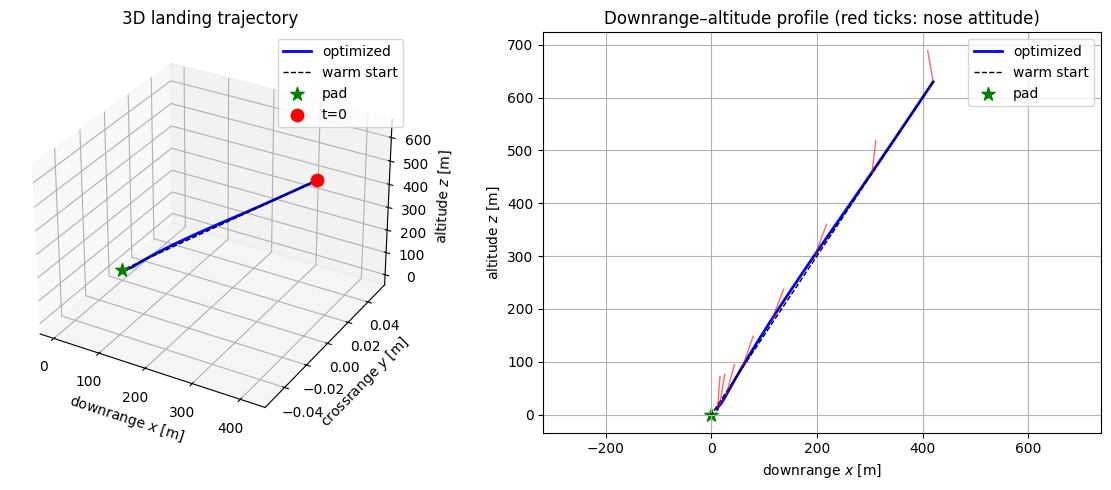

In [12]:
fig = plt.figure(figsize=(12, 5))

# --- 3D trajectory ---------------------------------------------------------
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(x_opt[:, 0], x_opt[:, 1], x_opt[:, 2], "b-", lw=2, label="optimized")
ax.plot(x_guess[:, 0], x_guess[:, 1], x_guess[:, 2], "k--", lw=1, label="warm start")
ax.scatter([0], [0], [0], c="g", s=100, marker="*", label="pad")
ax.scatter([x_opt[0, 0]], [x_opt[0, 1]], [x_opt[0, 2]],
           c="r", s=80, marker="o", label="t=0")
ax.set_xlabel("downrange $x$ [m]")
ax.set_ylabel("crossrange $y$ [m]")
ax.set_zlabel("altitude $z$ [m]")
ax.set_title("3D landing trajectory")
ax.legend()

# --- Downrange–altitude (canonical 2D view) --------------------------------
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(x_opt[:, 0], x_opt[:, 2], "b-", lw=2, label="optimized")
ax2.plot(x_guess[:, 0], x_guess[:, 2], "k--", lw=1, label="warm start")
# Draw little nose-vectors along the trajectory to show attitude
for k in range(0, N_NODES + 1, 4):
    ph, th, ps = x_opt[k, 6], x_opt[k, 7], x_opt[k, 8]
    nose_world = np.array([np.cos(ps) * np.sin(th) * np.cos(ph) + np.sin(ps) * np.sin(ph),
                           np.sin(ps) * np.sin(th) * np.cos(ph) - np.cos(ps) * np.sin(ph),
                           np.cos(th) * np.cos(ph)])
    ax2.plot([x_opt[k, 0], x_opt[k, 0] + 60 * nose_world[0]],
             [x_opt[k, 2], x_opt[k, 2] + 60 * nose_world[2]],
             "r-", lw=1, alpha=0.6)
ax2.scatter([0], [0], c="g", s=100, marker="*", label="pad")
ax2.set_xlabel("downrange $x$ [m]")
ax2.set_ylabel("altitude $z$ [m]")
ax2.set_title("Downrange–altitude profile (red ticks: nose attitude)")
ax2.set_aspect("equal", adjustable="datalim")
ax2.grid(True)
ax2.legend()
plt.tight_layout()
plt.show()


**Figure 1.** Left: 3D landing trajectory. Right: downrange–altitude view with red attitude ticks at every 4th node showing where the nose points. Optimized trajectory in blue, gravity-turn warm start in dashed black. The booster tips upright as it descends, with the pitch nearly zero by touchdown.


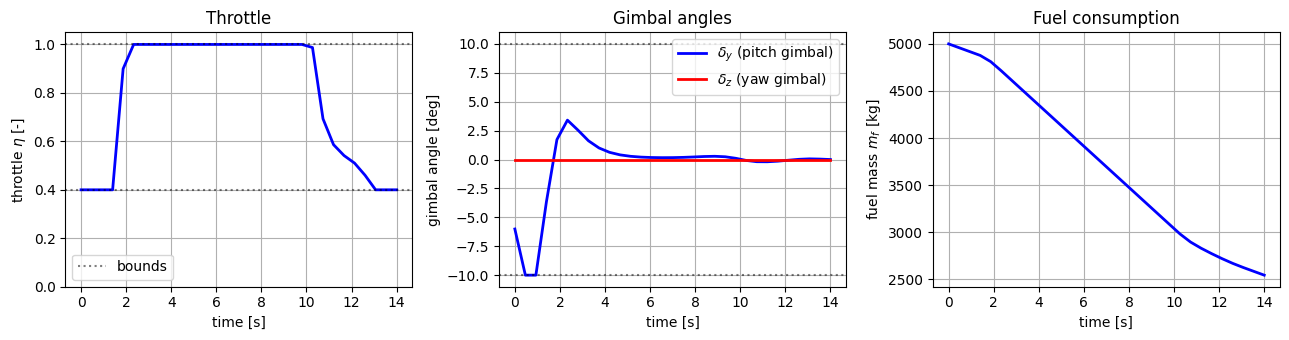

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# --- Throttle --------------------------------------------------------------
axes[0].plot(t_opt, u_opt[:, 0], "b-", lw=2)
axes[0].axhline(ETA_MIN, color="k", ls=":", alpha=0.5, label="bounds")
axes[0].axhline(ETA_MAX, color="k", ls=":", alpha=0.5)
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel(r"throttle $\eta$ [-]")
axes[0].set_title("Throttle")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True)
axes[0].legend()

# --- Gimbals ---------------------------------------------------------------
axes[1].plot(t_opt, np.rad2deg(u_opt[:, 1]), "b-", lw=2, label=r"$\delta_y$ (pitch gimbal)")
axes[1].plot(t_opt, np.rad2deg(u_opt[:, 2]), "r-", lw=2, label=r"$\delta_z$ (yaw gimbal)")
axes[1].axhline( np.rad2deg(DELTA_MAX), color="k", ls=":", alpha=0.5)
axes[1].axhline(-np.rad2deg(DELTA_MAX), color="k", ls=":", alpha=0.5)
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel(r"gimbal angle [deg]")
axes[1].set_title("Gimbal angles")
axes[1].grid(True)
axes[1].legend()

# --- Mass ------------------------------------------------------------------
axes[2].plot(t_opt, x_opt[:, 12], "b-", lw=2)
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel(r"fuel mass $m_f$ [kg]")
axes[2].set_title("Fuel consumption")
axes[2].grid(True)
plt.tight_layout()
plt.show()


**Figure 2.** Control histories and fuel mass. The throttle profile (left) is the classic bang-coast-bang of fuel-optimal landing: $\eta_\text{min}$ at the start to coast on momentum, $\eta_\text{max}$ during the deceleration phase, then $\eta_\text{min}$ at the end to feather the touchdown. The pitch gimbal (middle, blue) saturates briefly to rotate the booster's thrust vector against horizontal velocity, then reverses sign to swing it back upright. The yaw gimbal (red) stays at zero — the problem is symmetric in the $xz$ plane and the optimizer respects that. Mass (right) decreases at the rate determined by the throttle profile, with steeper slope where $\eta = 1$.


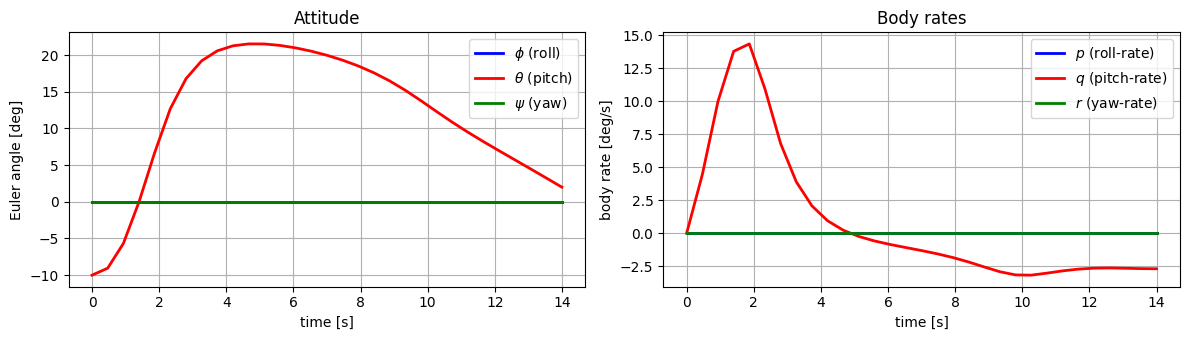

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(t_opt, np.rad2deg(x_opt[:, 6]), "b-", lw=2, label=r"$\phi$ (roll)")
axes[0].plot(t_opt, np.rad2deg(x_opt[:, 7]), "r-", lw=2, label=r"$\theta$ (pitch)")
axes[0].plot(t_opt, np.rad2deg(x_opt[:, 8]), "g-", lw=2, label=r"$\psi$ (yaw)")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("Euler angle [deg]")
axes[0].set_title("Attitude")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(t_opt, np.rad2deg(x_opt[:, 9]),  "b-", lw=2, label=r"$p$ (roll-rate)")
axes[1].plot(t_opt, np.rad2deg(x_opt[:, 10]), "r-", lw=2, label=r"$q$ (pitch-rate)")
axes[1].plot(t_opt, np.rad2deg(x_opt[:, 11]), "g-", lw=2, label=r"$r$ (yaw-rate)")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("body rate [deg/s]")
axes[1].set_title("Body rates")
axes[1].grid(True)
axes[1].legend()
plt.tight_layout()
plt.show()


**Figure 3.** Attitude histories. Pitch (red) starts at $-10^\circ$, swings up to about $+20^\circ$ as the booster's nose comes ``through'' vertical and tips downrange — this is where the thrust-against-velocity work is done — and then settles near zero by touchdown. Roll and yaw stay flat. The body-rate plot (right) shows the corresponding pitch-rate spike during the early reorientation, then a slow opposing sign as the attitude is brought back. Roll- and yaw-rates are zero throughout: the symmetry is preserved.


## Failure modes

**IC kinematic mismatch.** The single most sensitive knob is the relationship between $\boldsymbol{\xi}_0$, $\dot{\boldsymbol{\xi}}_0$, and $T_\text{burn}$. We chose them so that linear deceleration covers exactly the initial offset; if you push the initial position out by a factor of $\sim 2$ without lengthening $T_\text{burn}$, IPOPT either reports ``Restoration_Failed'' or returns a solution with tens of meters of position residual — there is simply not enough impulse to bend the trajectory in the available time.

**Throttle saturation regime.** With $T_\text{max}/m\,g \approx 2$ at full throttle, the soft-landing trajectory has the throttle bouncing between $\eta_\text{min} = 0.4$ (coast / fuel-saving phase) and $\eta_\text{max} = 1$ (decelerating phase). If $T_\text{max}$ is reduced so that the max thrust-to-weight ratio drops below $\sim 1.2$, the deceleration cannot overcome gravity *and* the descent velocity simultaneously; the booster can only break even with gravity at full throttle, and ground impact follows.

**Q_N too soft.** Drop the position weights in $Q_N$ from $1\times 10^5$ to $1$ and the booster will miss the pad by $\sim 100$ m, with the rest of the cost dominated by control effort. The terminal weights do real work.

**Gimbal saturation.** With a $\pm 10^\circ$ gimbal and these initial conditions, the optimal solution saturates the pitch gimbal early to swing the booster upright. Reduce `DELTA_MAX` to $5^\circ$ and the optimizer cannot reorient the booster in time; it solves but with several degrees of pitch error at touchdown — i.e. a soft crash. This reflects real engineering: gimbal authority sets the maneuver envelope.

**Coarse discretization.** With `N_NODES = 10` (down from 40), Hermite-Simpson collocation cannot resolve the initial transient where the throttle slams between $\eta_\text{min}$ and $\eta_\text{max}$; the energy residual jumps from percent-level to $\sim 10\%$. The cost of refinement is roughly linear in `N_NODES`.

**Initial condition far from feasibility.** Increase the downrange offset to several kilometers without scaling $T_\text{burn}$ accordingly and the warm start will not be in the basin of attraction of any feasible solution; the booster cannot redirect that much horizontal momentum with the available propellant. This is a *physical* infeasibility, not a numerical one — no solver will fix it.


## Exercises

1. **(Easy.)** Re-run the trajopt with `T_BURN = 10.0`, `15.0`, `18.0`. Plot fuel-used vs. burn duration. Where is the minimum?
2. **(Medium, code.)** Replace the linear gravity-turn guess with one that *integrates* the booster forward under the warm-start throttle and zero gimbals (i.e., let physics shape the guess). Does the optimizer converge faster? Use `jaxonomy.simulate` on a `Booster` driven by a `Constant` source.
3. **(Medium, code.)** Add a hard terminal constraint: pass `constrain_xf=True` and remove the corresponding $Q_N$ weights for position and velocity. Compare the optimized trajectory and solver iteration count.
4. **(Hard, conceptual.)** The cost function does not penalize fuel use directly — only via $R$ on the throttle. Re-derive a cost where the running cost is $T_\text{max}\,\eta_k\,\Delta t / (I_\text{sp} g_0)$ (literal mass burned per step), and discuss whether the result coincides with the throttle-quadratic version when the throttle saturates.
5. **(Open.)** Swap Z-Y-X Euler angles for unit quaternions. You will need: a 14-dim state (one extra component for $q_w$), an additional equality constraint $\|\mathbf{q}\|^2 = 1$ at every node, and the body-quaternion kinematics $\dot{\mathbf{q}} = \tfrac{1}{2}\mathbf{q} \otimes [0; \boldsymbol{\omega}]$. Does the solver still converge? At what cost?


## Key takeaways

- A 6-DOF rigid-body booster with variable mass is naturally one `LeafSystem` with 13 states and 3 controls; primitives composition would obscure the coupled dynamics.
- For soft-landing trajectories that stay within $\sim 30^\circ$ of vertical, Z-Y-X Euler angles are the right attitude representation: 3 dims, no unit-norm constraint, and the singularity at $\theta = \pm 90^\circ$ is irrelevant.
- Open-loop trajectory optimization with `jaxonomy.trajopt` (Hermite-Simpson + IPOPT) requires a sensible warm start. A linear-interpolation gravity-turn guess at a constant ``empty-the-tank'' throttle is enough to land in the basin of the soft-landing solution.
- Terminal-constraint accuracy is mainly set by the terminal weight $Q_N$. A direct equality constraint (`constrain_xf=True`) is available but harder to converge.
- Validation is cheap and load-bearing: terminal-state residuals plus an energy-balance check catch most integrator/dynamics bugs before they propagate to Part 2.

## Next steps

In **Part 2** we close the loop with model-predictive control, inject wind and mass-estimation-error disturbances, and render the resulting trajectory in MuJoCo via `jaxonomy.library.mujoco`. The trajectory we just optimized becomes the *reference* the MPC tracks; the dynamics here become the *model* the MPC uses internally; and the MuJoCo render lets us see the booster fly the maneuver.

## References

> [1] Açıkmeşe, B. & Ploen, S. R. (2007). *Convex programming approach to powered descent guidance for Mars landing.* Journal of Guidance, Control, and Dynamics, 30(5), 1353–1366. [The lossless-convexification reference for this problem class. We do not implement it; see the note above on direct-shooting vs. SOCP.]
>
> [2] Blackmore, L., Açıkmeşe, B., & Scharf, D. P. (2010). *Minimum-landing-error powered-descent guidance for Mars landing using convex optimization.* Journal of Guidance, Control, and Dynamics, 33(4), 1161–1171.
>
> [3] Lu, P. (2018). *Propellant-optimal powered descent guidance.* Journal of Guidance, Control, and Dynamics, 41(4), 813–826.
>
> [4] Betts, J. T. (2010). *Practical methods for optimal control and estimation using nonlinear programming* (2nd ed.). SIAM. [Reference for direct shooting and Hermite-Simpson collocation.]
